# Majorant_v2 — OPEN cascades (cases 3 and 4), BASELINE engine

Split out of `Run_four_cases_no_resampling.ipynb`. This notebook holds the two **open**
configurations; the two closed ones live in `Run_closed_no_resampling_v2.ipynb`.

Uses **`BF_v_no_resampling_v2.py`**: one simulated particle is one physical particle,
$w\equiv1$ for the whole run, so $\sum w$ and $\sum wm$ are conserved to machine precision
and `mass_drift` is *identically zero*.

| # | process | system | boundary conditions |
|---|---|---|---|
| 3 | coagulation  | open | injection at small $m$, absorbing sink at large $m$ |
| 4 | fragmentation| open | injection at large $m$, absorbing sink at small $m$ |

## What the analytic part predicts

$$\beta=\frac{1+\lambda}{2},\qquad b=\frac{1}{1-\beta}=\frac{2}{1-\lambda},\qquad
\alpha=-(1+\beta)=-\frac{3+\lambda}{2}$$

The open branch differs from the closed one only in what the collision partner is drawn
from: a stationary background $\propto m_0^{\alpha}$ instead of a mass-conserving packet
$\propto m_0^{-2}$. **Constant kernel, $\lambda=0$:** $b=2$, $\alpha=-3/2$.

## How the spectrum is measured here

The steady state **is** the instantaneous spectrum — use the **last snapshot**. $\Delta t$
never enters the estimator, so the snapshot cadence is irrelevant and `snapshot_mode="events"`
is fine. (`BF.superpose` is for the closed notebook and is wrong here.)

## Three things this notebook does that the four-case one did not

1. **The sink gates the isochrones, in both processes.** `iso_start_sink` is armed by
   default at 10 absorptions, so ages are binned only once mass has demonstrably crossed
   the whole inertial range. Case 4 now requests isochrones too.
2. **Panel (b) is compensated:** $m^2\,dN/dm$, i.e. **mass per logarithmic mass interval**,
   with the isochrones drawn underneath the steady state. How many isochrones to show is a
   knob at the top of each figure cell, and the cell prints how many are available first.
3. **The theory is checked against the plateau.** `find_inertial_range` — the longest flat
   run in $\Gamma(m)=d\log F/d\log m$ — supplies the measured index, and *that* is the model
   drawn on panel (b). The a-priori guard band survives only as a cross-check.

> ### Engine: `BF_v_no_resampling_v2.py`
>
> Same physics, same majorant, same clock and the same analysis helpers as
> `BF_v_no_resampling.py`. Four additions, all about the **sink as a criterion**:
>
> 1. `iso_start_sink` now defaults to **10** and applies to coagulation *and* fragmentation
>    alike — the sink is the sink, whichever end of the cascade it sits at. Isochrone
>    accumulation waits until 10 physical particles have crossed the whole inertial range.
> 2. A closed system has no sink, so that default is silently disarmed there; only an
>    explicitly passed value still raises.
> 3. `stop_sink_events` (new, default `None`) — stop the run on the sink count. `max_events`
>    is a statement about *resources*; this one is a statement about the *physics*.
> 4. `out["n_out"]` (new) — the sink counter as a per-snapshot time series, next to the
>    existing final scalar `out["sink_events"]`.
>
> The original `BF_v_no_resampling.py` and `Run_four_cases_no_resampling.ipynb` are untouched.


> ### ⚠ Fit only the inertial range — never the whole array
>
> A measured spectrum is a power law only *between* the two characteristic masses of the
> problem. Outside that band it bends: at the injection scale by the source, at the sink by
> truncation and by vanishing statistics. A single fit across the whole array averages the
> plateau together with both bends and returns a number describing neither.
>
> **In this notebook the plateau is the answer.** `BF.find_inertial_range(m, F)` returns the
> longest contiguous run over which the local slope $\Gamma(m)=d\log F/d\log m$ stays flat
> within `tol`, together with that run's mean, its scatter, and its width in decades. That
> mean is the measured $\alpha$, it is what goes into the summary table, and it is what is
> drawn on panel (b). If it returns `nan`, the run has no inertial range yet — the correct
> answer, not a failure.
>
> `BF.guard_band(m_low, m_high)` — strip 0.5 dex from each end of $[m_{\rm inj},m_{\rm sink}]$ —
> is kept as an **independent cross-check**. The two must agree; if they do not, the cascade
> has not developed over the range you assumed.
>
> A plateau narrower than about one decade is not a power law, however tight its error bar.
> The `decades` column in the summary is there to be read.
>
> One trap worth stating once: the plateau finder tests whether *the curve you computed* has
> a scaling region, not whether that curve is the right quantity. It cannot rescue a broken
> estimator. Here the estimator is the last snapshot of an open run, which is exempt from the
> $\Delta t$-weighting trap that afflicts the closed notebook.


In [27]:
import importlib, inspect, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import BF_v_no_resampling_v2 as BF          # <-- v2 baseline engine, w == 1
importlib.reload(BF)

plt.rcParams.update({"figure.dpi":110, "font.size":9, "axes.grid":True,
                     "grid.alpha":0.25, "figure.figsize":(9,3.2)})

KERNEL = BF.kernel_geometric         # lambda = 2/3 (geometric cross section)
LAM    = BF.KERNEL_LAMBDA[KERNEL.__name__]
EDGES  = 10.0 ** np.arange(-4, 12, 0.1)   # top edge 10^7.9; see check_grid below


def check_grid(*masses):
    """
    Refuse to start if a characteristic mass falls outside the bin grid.

    The bin-pair majorant is built from the bin UPPER CORNERS.  mass_to_bin
    CLAMPS anything above the top edge into the last bin -- whose corner is
    then SMALLER than the particle itself -- so K(m,m) exceeds its own
    majorant and the engine raises "Majorant violated" on the very first
    pair.  With the constant kernel this could never happen (K = 1 flat).
    With any lambda > 0 it is an immediate hard crash, and the traceback
    points at the majorant, not at the grid.  Check up front instead.
    """
    lo, hi = EDGES[0], EDGES[-1]
    bad = [float(m) for m in masses if not (lo < m < hi)]
    if bad:
        raise ValueError("masses %s fall outside the grid (%.3g, %.3g) -- widen EDGES"
                         % (bad, lo, hi))

assert "stop_sink_events" in inspect.signature(BF.simulate).parameters, \
    "the engine on the path is not BF_v_no_resampling_v2.py"

print("engine =", BF.__name__)
print("kernel =", KERNEL.__name__, " lambda =", LAM)
PR = BF.predict("open", LAM)
print("  open   beta = %.4g   b = %.4g   alpha = %.4g" % (PR["beta"], PR["b"], PR["alpha"]))
print("  grid   %.3g .. %.3g  (%d bins of %.2f dex)"
      % (EDGES[0], EDGES[-1], EDGES.size-1, np.log10(EDGES[1]/EDGES[0])))

# Age bins must be chosen from b, not copied from the lambda = 0 notebook.  One age
# bin of width D_tau dex covers b * D_tau dex of MASS, so at b = 6 the old 0.15 dex
# step jumps 0.9 dex of mass per bin and the growth-law mask catches two bins.
# Fix the MASS resolution instead and let the age step follow.
AGE_STEP = 0.30 / PR["b"]          # 0.15 at b=2 (identical to the constant-kernel run)
print("  ages   %.3f dex per bin  ->  %.2f dex of mass per bin" % (AGE_STEP, 0.30))

RESULTS = {}   # collected for the summary table at the end


engine = BF_v_no_resampling_v2
kernel = kernel_geometric  lambda = 0.6666666666666666
  open   beta = 0.8333   b = 6   alpha = -1.833
  grid   0.0001 .. 7.94e+11  (159 bins of 0.10 dex)
  ages   0.050 dex per bin  ->  0.30 dex of mass per bin


In [28]:
# ----------------------------------------------------------------------
#  Two helpers used by the figures below.  Pure presentation: neither one
#  touches a measurement, and neither is allowed to move a fitted slope.
# ----------------------------------------------------------------------

def anchor_amplitude(m, F, m_lo, m_hi, alpha):
    """
    A such that  A * m**alpha  runs through the data over [m_lo, m_hi].

    find_inertial_range returns the plateau INDEX and no normalisation, so the
    line has to be anchored to the data somehow.  This is the least-squares
    intercept at FIXED slope: the drawn model carries the plateau index and
    nothing else -- no second fit is allowed to quietly adjust it.  Using the
    same routine for the theory line makes the two curves differ in SLOPE ONLY,
    which is the whole point of drawing them together.
    """
    m = np.asarray(m, float); F = np.asarray(F, float)
    if not (np.isfinite(m_lo) and np.isfinite(m_hi) and np.isfinite(alpha)):
        return np.nan
    k = np.isfinite(F) & (F > 0) & (m >= m_lo) & (m <= m_hi)
    if k.sum() < 3:
        return np.nan
    return 10.0 ** np.mean(np.log10(F[k]) - alpha * np.log10(m[k]))


def pick_isochrones(run, n_show, min_frac=1e-4):
    """
    Choose which isochrones to draw, and report how many there were to choose from.

    An age bin counts as usable if its total is at least `min_frac` of the
    fullest bin -- otherwise a handful of nearly empty bins drag the y-axis down
    by four decades and hide everything worth looking at.  `n_show` of the
    survivors are then taken evenly in log(age).

    Returns (indices, tau_centres, n_available), so the caller can PRINT
    n_available before drawing: you should always know what fraction of the
    isochrones you are actually looking at.
    """
    if "iso_dndm" not in run:
        return np.array([], int), np.array([]), 0
    iso = np.asarray(run["iso_dndm"], float)
    e   = np.asarray(run["iso_age_edges"], float)
    tau = np.sqrt(e[:-1] * e[1:])                       # geometric bin centres
    tot = iso.sum(axis=1)
    if not np.any(tot > 0):
        return np.array([], int), tau, 0
    usable = np.flatnonzero(tot > min_frac * tot.max())
    if usable.size == 0 or n_show >= usable.size:
        return usable, tau, usable.size
    pick = np.unique(np.linspace(0, usable.size - 1, int(n_show)).astype(int))
    return usable[pick], tau, usable.size


def draw_isochrones(ax, run, idx, tau, tau_scale=1.0, cbar_label=r"age $\tau N$",
                    min_count=3.0):
    """
    Overlay the selected isochrones, coloured by age, with a colourbar.

    Mass bins holding fewer than `min_count` particles are blanked: at the ends
    of an isochrone the histogram is one or two counts wide and draws a spiky
    tail that is pure shot noise, not spectrum.
    """
    if len(idx) == 0:
        return
    c    = np.asarray(run["centers"], float)
    cnt  = np.asarray(run["iso_counts"], float)
    nsnp = max(run["iso_snapshots"], 1)
    t_lo, t_hi = tau[idx].min()*tau_scale, tau[idx].max()*tau_scale
    norm = LogNorm(vmin=t_lo, vmax=max(t_hi, t_lo*1.0001))
    cm   = plt.cm.viridis
    for k in idx:
        y = run["iso_dndm"][k] / nsnp
        ok = (y > 0) & (cnt[k] >= min_count)
        ax.loglog(c, np.where(ok, y * c**2, np.nan), lw=1.2, alpha=.9,
                  color=cm(norm(tau[k]*tau_scale)), zorder=1)
    sm = plt.cm.ScalarMappable(cmap=cm, norm=norm); sm.set_array([])
    cb = ax.figure.colorbar(sm, ax=ax, pad=.02, fraction=.05)
    cb.set_label(cbar_label, fontsize=7); cb.ax.tick_params(labelsize=6)


def compensated_ylim(ax, m, F, lo=3e-5, hi=4.0):
    """Frame panel (b) on the steady state, not on the faintest isochrone."""
    y = np.asarray(F, float) * np.asarray(m, float)**2
    top = np.nanmax(np.where(np.isfinite(y) & (y > 0), y, np.nan))
    if np.isfinite(top) and top > 0:
        ax.set_ylim(top*lo, top*hi)


---
## 3. Open system + coagulation

Injection of monomers at $m_{\rm inj}$, absorbing sink at $m_{\rm sink}$. A genuine steady
state now exists, and **the spectrum is the last snapshot, not a superposition**.

Steady-state estimate for the injection rate (constant kernel, $V=1$): the accepted event
rate is $\simeq N^2/2$, so $q\simeq N_{\rm ss}^2/2$ up to the number of mergers each monomer
needs. Tune `q` until `live` plateaus and $M_{\rm out}/M_{\rm in}\to1$.

The growth law is measured from the **isochrones** — the accumulated 2D histogram in
(age, mass) — as $\langle m\rangle(\tau)\propto\tau^{\,b}$ with $b=2/(1-\lambda)=2$.

> ### ⚠ Nothing in an open run may be gated on an *absolute* time
>
> The clock is $dt=2V/(wR)$ with $R\propto N^2$, so the time reached after $E$ majorant
> attempts is **$t=2E/N^2$ exactly**. Raising $N_{\rm ss}$ at fixed `max_events` therefore
> makes the run *shorter*, not better: at $E=1.2\times10^6$, $N=10^4$ reaches $t=2.4\times10^{-2}$
> but $N=10^5$ only $2.4\times10^{-4}$. A gate such as the old `iso_t_start=2e-3`, tuned at one
> $N$, is then never crossed, `iso_counts` stays identically zero, and $b$ comes back as `nan`
> — with the isochrone panel crashing on the empty selection. The engine now raises a
> `RuntimeWarning` in that case instead of failing silently.
>
> **The two invariants.**
> - *Events per particle*, not events: `max_events` must scale $\propto N_{\rm ss}$ for the same
>   physics, since $t\cdot N=2E/N$.
> - Everything measured in time belongs in units of the collision time $t_c=1/(K n)=1/N_{\rm ss}$
>   — including `iso_age_edges`, because particle ages scale as $1/N$ too.
>
> **The gate itself is better stated physically.** `iso_start_sink=100` starts the isochrones
> only once the sink has absorbed 100 particles: an $N$-independent statement that mass has
> demonstrably crossed the whole inertial range. Its cost follows from the mass budget — the
> box holds $\simeq N\sqrt{m_{\rm sink}}$ in steady state and $n_{\rm out}$ absorptions carry off
> $n_{\rm out}m_{\rm sink}$ — so
>
> $$E\;\simeq\;N\sqrt{m_{\rm sink}}\;+\;n_{\rm out}\,m_{\rm sink}.$$
>
> The second term is independent of $N$: the gate does not get more expensive as the run grows,
> only filling the box does. Measured at $N=10^4$, $m_{\rm sink}=10^3$: the 100th absorption
> lands at $t\cdot N=72$ against the 83 predicted, and the isochrones then give $b=2.025$
> (theory 2).

In [ ]:
# OPEN system: the steady state is the LAST snapshot, dt never enters the estimator,
# so snapshotting by events is perfectly fine here.
#
# The isochrone gate is PHYSICAL, not temporal: bin ages only after the sink has swallowed
# N_OUT particles.  In v2 that gate is armed by default (10) for BOTH processes; it is passed
# explicitly below only to keep the number visible next to the budget it implies.

N_SS   = 1e6
M_INJ  = 1.0
M_SINK = 1e5
N_OUT  = 10                                    # sink absorptions before binning ages
N_STOP = 100                                   # sink absorptions before STOPPING (see below)
MAX_EV = 1.5e7                                 # resource ceiling, whichever comes first
check_grid(M_INJ, M_SINK)

# --- injection rate: the one constant that does NOT survive a change of kernel ------
# Number balance in steady state:  q = accepted event rate = <K> N^2 / (2V).
# The original notebook wrote q = N^2/2, which is that formula with <K> = 1 -- true for
# the CONSTANT kernel and for nothing else.  N is dominated by the injection scale
# (alpha < -1), so most pairs are (m_inj, m_inj) and <K> is of order K(m_inj, m_inj);
# heavier partners push it up by roughly a factor two, so `live` settles somewhat below
# N_SS.  That is fine.  What matters is that panel (a) shows a PLATEAU and M_out/M_in
# heads for 1 -- retune K_TYP by hand if it drifts.
K_TYP  = KERNEL(M_INJ, M_INJ)                  # 1.0 for the constant kernel, 4.0 here
q3     = 0.5 * K_TYP * N_SS**2
t_c    = 1.0 / (K_TYP * N_SS)                  # collision time per particle: 1/(K n), V = 1
print("K(m_inj,m_inj) = %.4g   ->   q = %.3e,   t_c = %.3e" % (K_TYP, q3, t_c))

# Cost, measured for THIS kernel: 100 absorptions at m_sink = 1e5 take ~1.2e7 events.
# The notebook's own estimate  E ~ N*sqrt(m_sink) + n_out*m_sink  was derived at
# lambda = 0 and overshoots here, because a geometric kernel drives mass to the sink
# faster per event.  Both brakes are armed and sized to bite at about the same place;
# r3["stop_reason"] then says which one actually did.
print("brakes: stop_sink_events = %d   |   max_events = %.2e" % (N_STOP, MAX_EV))

r3 = BF.simulate(process="coagulation", system="open", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INJ, "N":N_SS}, injection_rate=q3, injection_mass=M_INJ,
                 sink_mass=M_SINK,
                 snapshot_mode="events", snapshot_stride=max(int(MAX_EV)//200, 1),
                 # max_events=np.inf is only safe when SOMETHING ELSE can stop the run.
                 # In an OPEN COAGULATION run nothing else can: live sits on a plateau so
                 # `live < 2` never fires, stop_max/min_mass are None, and the stall guard
                 # stays quiet because events keep being accepted.  Without the line below
                 # this cell runs forever.  stop_sink_events is the v2 brake and, unlike
                 # max_events, it means the same thing at every kernel -- but keep a
                 # resource ceiling as well, so a mistuned q cannot cost an afternoon.
                 max_events=MAX_EV, stop_sink_events=N_STOP,
                 iso_age_edges=10.0**np.arange(-3, 3, AGE_STEP) * t_c,
                 iso_start_sink=N_OUT,          # the gate (v2 default is 10 anyway)
                 age_rule="mass_weighted",      # report this; try 'min' to test sensitivity
                 rng=np.random.default_rng(3), verbose=False)

print("live %d -> %d   (must plateau)" % (r3["live"][0], r3["live"][-1]))
print("sink absorptions = %d  (gate asks for %d) | M_out/M_in = %.3f  (must approach 1)"
      % (r3["sink_events"], N_OUT, r3["M_out"][-1]/max(r3["M_in"][-1],1)))
print("isochrones: %d snapshots, accumulation began at t = %.3g  (t*N = %.0f)"
      % (r3["iso_snapshots"], r3["iso_t_begin"], r3["iso_t_begin"]*N_SS))
print("run ended at t = %.3g  (t*N = %.0f) | stop = %s"
      % (r3["t"][-1], r3["t"][-1]*N_SS, r3["stop_reason"]))

# ---------------- the spectrum -------------------------------------------------
last3 = r3["dndm"][-1]

# THE measurement: the longest plateau in the local slope.  Everything downstream --
# the model on panel (b), the summary row -- reads this and nothing else.
ir3 = BF.find_inertial_range(r3["centers"], last3)

# a-priori band, kept only as an independent cross-check.  NOTE the upper scale is M_SINK,
# per guard_band's own docstring (open system: [m_inj, m_sink]).
gb3 = BF.guard_band(M_INJ, M_SINK, 0.5)
f3  = BF.fit_powerlaw(r3["centers"], last3, *gb3)
pr3 = PR

# ---------------- the growth law, from the isochrones --------------------------
tau3, mbar3, n3 = BF.iso_mean_mass(r3["iso_counts"], r3["centers"], r3["iso_age_edges"])
# The window was hard-coded (3, 300) for the constant kernel.  Tie it to the guard band
# instead: fit the growth law only where the spectrum itself is a clean power law.  At
# b = 6 a 2-decade mass window is a THIRD of a decade in tau and catches two age bins.
k3 = np.isfinite(mbar3) & (n3 > 1e3) & (mbar3 > gb3[0]) & (mbar3 < gb3[1])
b3 = np.polyfit(np.log(tau3[k3]), np.log(mbar3[k3]), 1)[0] if k3.sum() > 3 else np.nan

print("\nspectrum, AUTO PLATEAU [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades   <== the answer"
      % (ir3["m_lo"], ir3["m_hi"], ir3["alpha"], ir3["scatter"], ir3["decades"]))
print("spectrum, guard band   [%.3g,%.3g] : alpha = %+.3f   R2 = %.3f   (cross-check)"
      % (gb3[0], gb3[1], f3["alpha"], f3["r2"]))
print("theory                              : alpha = %+.3f   b = %.3f" % (pr3["alpha"], pr3["b"]))
print("isochrone growth                    : b = %.3f   [%d age bins]" % (b3, k3.sum()))
if k3.sum() <= 3:
    print("  !! too few usable age bins: %d iso snapshots, %d sink absorptions."
          "  Raise N_STOP (cost ~ N*sqrt(m_sink) + n_out*m_sink) or lower M_SINK."
          % (r3["iso_snapshots"], r3["sink_events"]))

RESULTS["3 open coag"] = dict(b=b3, b_th=pr3["b"], alpha=ir3["alpha"], alpha_th=pr3["alpha"],
                              scatter=ir3["scatter"], decades=ir3["decades"],
                              alpha_gb=f3["alpha"])


K(m_inj,m_inj) = 4   ->   q = 2.000e+08,   t_c = 2.500e-05
brakes: stop_sink_events = 10   |   max_events = 1.50e+07
live 10000 -> 7037   (must plateau)
sink absorptions = 10  (gate asks for 10) | M_out/M_in = 0.973  (must approach 1)
isochrones: 1 snapshots, accumulation began at t = 0.00551  (t*N = 55)
run ended at t = 0.00551  (t*N = 55) | stop = stop_sink_events

spectrum, AUTO PLATEAU [8.91,141] : alpha = -1.896 +- 0.162  over 1.20 decades   <== the answer
spectrum, guard band   [3.16,3.16e+04] : alpha = -1.834   R2 = 0.983   (cross-check)
theory                              : alpha = -1.833   b = 6.000
isochrone growth                    : b = nan   [0 age bins]
  !! too few usable age bins: 1 iso snapshots, 10 sink absorptions.  Raise N_STOP (cost ~ N*sqrt(m_sink) + n_out*m_sink) or lower M_SINK.


isochrones: 78 of 119 age bins carry statistics -> drawing 78


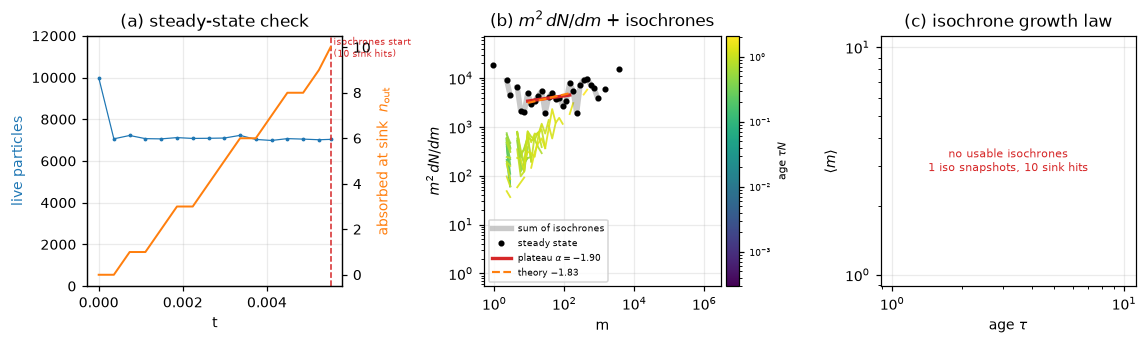

In [30]:
N_ISO_SHOW = 100      # <<-- how many isochrones to draw on panel (b).  The line below prints
                    #      how many are available first, so you always know what you are seeing.
                    #      NOTE: AGE_STEP is now 0.05 dex (b = 6), so there are ~119 age bins
                    #      instead of 39 and "100" really does draw ~70 curves.  Drop to ~12
                    #      if panel (b) turns into a hairball.

idx3, tau3c, navail3 = pick_isochrones(r3, N_ISO_SHOW)
print("isochrones: %d of %d age bins carry statistics -> drawing %d"
      % (navail3, len(tau3c), len(idx3)))

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))

# ---- (a) steady-state check, with the sink counter on the right axis ----------
ax[0].plot(r3["t"], r3["live"], ".-", ms=3, lw=.8, color="C0")
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles", color="C0")
ax[0].set_ylim(0, 1.2*np.max(r3["live"]))      # start at zero: no offset trick on this axis
ax[0].set_title("(a) steady-state check")
axr = ax[0].twinx(); axr.grid(False)
axr.plot(r3["t"], r3["n_out"], "-", lw=1.3, color="C1")
axr.set_ylabel(r"absorbed at sink  $n_{\rm out}$", color="C1")
if np.isfinite(r3["iso_t_begin"]):
    ax[0].axvline(r3["iso_t_begin"], ls="--", lw=1, color="C3")
    ax[0].text(r3["iso_t_begin"], ax[0].get_ylim()[1], " isochrones start\n (%d sink hits)" % N_OUT,
               fontsize=6, va="top", color="C3")

# ---- (b) COMPENSATED spectrum: m^2 dN/dm = mass per logarithmic mass interval --
c = r3["centers"]
a = ax[1]
draw_isochrones(a, r3, idx3, tau3c, tau_scale=N_SS)
if len(idx3):
    # completeness check: the isochrones must add up to the steady state
    iso_sum = r3["iso_dndm"].sum(axis=0) / max(r3["iso_snapshots"], 1)
    a.loglog(c, np.where(iso_sum > 0, iso_sum*c**2, np.nan), "-", lw=3.5, alpha=.35,
             color="0.4", zorder=2, label="sum of isochrones")
a.loglog(c, np.where(last3 > 0, last3*c**2, np.nan), "o", ms=3, color="k", zorder=4,
         label="steady state")

xs  = np.logspace(np.log10(ir3["m_lo"]), np.log10(ir3["m_hi"]), 30)
A_m = anchor_amplitude(c, last3, ir3["m_lo"], ir3["m_hi"], ir3["alpha"])
A_t = anchor_amplitude(c, last3, ir3["m_lo"], ir3["m_hi"], pr3["alpha"])
a.loglog(xs, A_m * xs**ir3["alpha"] * xs**2, "-",  lw=2.2, color="C3", zorder=5,
         label=r"plateau $\alpha=%.2f$" % ir3["alpha"])
a.loglog(xs, A_t * xs**pr3["alpha"] * xs**2, "--", lw=1.4, color="C1", zorder=5,
         label=r"theory $%.2f$" % pr3["alpha"])
compensated_ylim(a, c, last3)
a.set_xlim(.5, 3e6); a.set_xlabel("m"); a.set_ylabel(r"$m^2\,dN/dm$")
a.legend(fontsize=6, loc="lower left"); a.set_title(r"(b) $m^2\,dN/dm$ + isochrones")

# ---- (c) isochrone growth law -------------------------------------------------
if k3.sum() > 3:
    ax[2].loglog(tau3[k3], mbar3[k3], "o", ms=3)
    ax[2].loglog(tau3[k3], mbar3[k3][0]*(tau3[k3]/tau3[k3][0])**b3, "-", lw=1,
                 label=r"$\langle m\rangle\propto\tau^{%.2f}$ (theory %.0f)" % (b3, pr3["b"]))
    ax[2].legend(fontsize=7)
else:
    ax[2].set_xscale("log"); ax[2].set_yscale("log")
    ax[2].text(.5, .5, "no usable isochrones\n%d iso snapshots, %d sink hits"
               % (r3["iso_snapshots"], r3["sink_events"]),
               ha="center", va="center", fontsize=7, color="C3", transform=ax[2].transAxes)
ax[2].set_xlabel(r"age $\tau$"); ax[2].set_ylabel(r"$\langle m\rangle$")
ax[2].set_title("(c) isochrone growth law")
fig.tight_layout()


---
## 4. Open system + fragmentation

Injection of **large** bodies at $m_{\rm inj}$, absorbing sink at **small** $m_{\rm sink}$.
Mirror of case 3, and the theory predicts the same $\alpha=-(3+\lambda)/2$.

### The locality trap — run this one twice

If the rule is *"the heavier of the pair breaks, whatever hit it"*, the disruption rate of a
particle of mass $m_0$ is

$$\nu(m_0)\sim\int_{m_{\rm sink}}^{m_0}F(m')\,K(m_0,m')\,dm'\ \sim\ \int_{m_{\rm sink}/m_0}x^{\alpha}\,dx ,$$

which **diverges at the lower limit whenever $\alpha<-1$**. The drift is then controlled by
the smallest particles in the box — by the sink scale, not by $m_0$ — the mean-field closure
is void, $\beta\to1$, and the measured index locks onto $-2$ for *any* kernel. That is a
boundary effect masquerading as universality.

The cure is the one Dohnanyi (1969) built in: a **catastrophic-disruption threshold**. A
grain of dust does not shatter a boulder. Requiring $m_{\rm small}\ge f\,m_{\rm large}$ with
$f=O(0.1\!-\!1)$ restricts the integral to $x\in[f,1]$, which is scale free, and recovers
$\alpha=-(3+\lambda)/2$.

A **closed** system is immune, because its packet is narrow and all partners are already of
order $m_0$ — which is why cases 1 and 2 agree with the theory with no threshold at all.

In [31]:
# RANGE IS CAPPED BY MEMORY, not by taste.  Without resampling a completed cascade holds
# N0 * m_inj/m_sink particles, one array slot each.  m_inj = 1e7 asks for 1e10 of them --
# and it never even got that far: 1e7 sits ABOVE the old top edge 10^6.9, mass_to_bin
# clamped it into the last bin, and the very first pair tripped
#     RuntimeError: Majorant violated: K(1e+07,1e+07) > fmaj[108,108]
# 4 decades with N0 = 400 needs 4e6 particles (~130 MB) and the cascade can actually
# COMPLETE inside the event budget, which the old 1e4/1000/9e5 combination could not.
M_INJ4, M_SINK4 = 1.0e4, 1.0
N04   = 400
ME4   = 5.0e6                                  # ~ N0*m_inj/m_sink, i.e. a completed cascade
check_grid(M_INJ4, M_SINK4)

# Same story as q3: the target population is what a full cascade holds, and the kernel
# is evaluated where the NUMBER lives, i.e. at the sink scale.
N_FULL4 = N04 * M_INJ4 / M_SINK4
q4      = 0.5 * KERNEL(M_SINK4, M_SINK4) * N_FULL4**2 / (M_INJ4/M_SINK4)
t_c4    = 1.0 / (KERNEL(M_INJ4, M_INJ4) * N04)   # collision time at the START of the run
print("N_full = %.3g   q4 = %.3e   t_c4 = %.3e" % (N_FULL4, q4, t_c4))

runs4 = {}
for f_ratio in (0.0, 0.3):
    runs4[f_ratio] = BF.simulate(
        process="fragmentation", system="open", kernel=KERNEL, edges=EDGES,
        ic={"m":M_INJ4, "N":N04}, frag_min_ratio=f_ratio,
        injection_rate=q4/max(f_ratio,0.15)*0.15,
        injection_mass=M_INJ4, sink_mass=M_SINK4,
        snapshot_mode="events", snapshot_stride=int(ME4//150), max_events=ME4,  # 150 snapshots:
        # isochrone histogram is accumulated ONCE PER SNAPSHOT, so a coarse cadence
        # starves it.  Snapshots are cheap here; ages are not.
        # v2: isochrones for FRAGMENTATION too, gated on the same physical criterion.
        iso_age_edges=10.0**np.arange(-3, 3, AGE_STEP) * t_c4,
        iso_start_sink=10,
        rng=np.random.default_rng(4), verbose=False)

pr4 = BF.predict("open", LAM)
print("theory alpha = %+.3f,  b = %.3f\n" % (pr4["alpha"], pr4["b"]))

fits4, irs4, iso4 = {}, {}, {}
for f_ratio, r in runs4.items():
    last = r["dndm"][-1]
    irs4[f_ratio]  = BF.find_inertial_range(r["centers"], last)     # <== the measurement
    fits4[f_ratio] = BF.fit_powerlaw(r["centers"], last,
                                     *BF.guard_band(M_SINK4, M_INJ4, 0.4))   # cross-check

    # Decay law.  Open fragmentation shrinks a body with age, so <m> is read in
    # (tau* - tau) exactly as closed fragmentation is in case 2: m ~ (tau*-tau)^b
    # means m^(1/b) is LINEAR in tau, so tau* comes from where that line crosses zero.
    tau, mbar, nn = BF.iso_mean_mass(r["iso_counts"], r["centers"], r["iso_age_edges"])
    kk = np.isfinite(mbar) & (nn > 1e3) & (mbar > 3*M_SINK4) & (mbar < 0.3*M_INJ4)
    if kk.sum() > 3:
        pl     = np.polyfit(tau[kk], mbar[kk]**(1.0/pr4["b"]), 1)
        t_star = -pl[1]/pl[0]
        g      = BF.growth_fit(tau, mbar, t_star=t_star*1.0000001, mask=kk)
        b4     = g["b"]
    else:
        t_star, b4 = np.nan, np.nan
    iso4[f_ratio] = dict(tau=tau, mbar=mbar, n=nn, k=kk, t_star=t_star, b=b4)

    # Why the isochrones can still be thin here.  Injection at m_inj delivers only a
    # handful of bodies over the time this run reaches, so essentially every live
    # particle still descends from the INITIAL CONDITION and inherits t_born = 0.
    # Age then equals wall-clock time for everyone at once and the age axis is
    # degenerate -- the isochrones degrade into "spectrum vs time".  The same fact
    # shows up as M_out/M_in > 1: the sink is draining the initial reservoir, whose
    # mass never entered M_in.  A real age spectrum needs the injected flux to
    # dominate, i.e. a much longer run (or BF.py, with weights).
    frac_ic = float(np.mean(r["final_inj_time"] == 0.0))

    tag = "NON-LOCAL (no threshold)" if f_ratio == 0 else ("local, f = %.2g" % f_ratio)
    ir  = irs4[f_ratio]
    print("  %-26s live %d->%d  sink=%d  M_out/M_in=%.2f" %
          (tag, r["live"][0], r["live"][-1], r["sink_events"],
           r["M_out"][-1]/max(r["M_in"][-1], 1)))
    print("      plateau  [%9.3g,%9.3g] alpha = %+.3f +- %.3f over %.2f dec   <== the answer"
          % (ir["m_lo"], ir["m_hi"], ir["alpha"], ir["scatter"], ir["decades"]))
    print("      guard band                     alpha = %+.3f   R2 = %.3f   (cross-check)"
          % (fits4[f_ratio]["alpha"], fits4[f_ratio]["r2"]))
    print("      isochrones: %d snapshots, %d usable age bins, b = %.3f (theory %.0f)"
          % (r["iso_snapshots"], kk.sum(), b4, pr4["b"]))
    print("      %.1f%% of live particles still descend from the IC (t_born = 0):"
          " while this is near 100%%, the age axis is degenerate and b is not a measurement"
          % (100*frac_ic))

for f_ratio in runs4:
    ir = irs4[f_ratio]
    RESULTS["4 open frag f=%.2g" % f_ratio] = dict(
        b=iso4[f_ratio]["b"], b_th=pr4["b"], alpha=ir["alpha"], alpha_th=pr4["alpha"],
        scatter=ir["scatter"], decades=ir["decades"], alpha_gb=fits4[f_ratio]["alpha"])


N_full = 4e+06   q4 = 3.200e+09   t_c4 = 1.347e-06
theory alpha = -1.833,  b = 6.000

  NON-LOCAL (no threshold)   live 400->4589737  sink=415315  M_out/M_in=0.00
      plateau  [      nan,      nan] alpha = +nan +- nan over 0.00 dec   <== the answer
      guard band                     alpha = -2.964   R2 = 0.978   (cross-check)
      isochrones: 151 snapshots, 55 usable age bins, b = 4.667 (theory 6)
      8.3% of live particles still descend from the IC (t_born = 0): while this is near 100%, the age axis is degenerate and b is not a measurement
  local, f = 0.3             live 400->3468642  sink=1536759  M_out/M_in=0.02
      plateau  [     3.55, 2.82e+03] alpha = -1.904 +- 0.150 over 2.90 dec   <== the answer
      guard band                     alpha = -1.905   R2 = 0.998   (cross-check)
      isochrones: 151 snapshots, 21 usable age bins, b = 4.560 (theory 6)
      14.4% of live particles still descend from the IC (t_born = 0): while this is near 100%, the age axis is degenerate

f = 0 : 43 of 119 age bins carry statistics -> drawing 10
f = 0.3 : 19 of 119 age bins carry statistics -> drawing 10


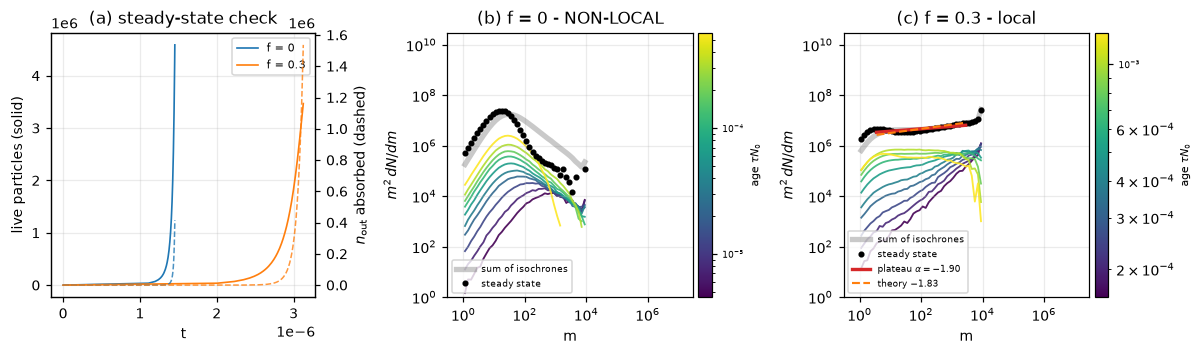

In [32]:
N_ISO_SHOW4 = 10     # <<-- isochrones per panel; availability is printed below

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))

# ---- (a) population and sink flux, both runs ---------------------------------
axr = ax[0].twinx(); axr.grid(False)
for i, (f_ratio, r) in enumerate(runs4.items()):
    ax[0].plot(r["t"], r["live"], "-", lw=1.1, color="C%d" % i, label="f = %.2g" % f_ratio)
    axr.plot(r["t"], r["n_out"], "--", lw=1.0, color="C%d" % i, alpha=.8)
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles (solid)")
axr.set_ylabel(r"$n_{\rm out}$ absorbed (dashed)")
ax[0].legend(fontsize=7); ax[0].set_title("(a) steady-state check")

# ---- (b),(c) compensated spectra with isochrones -----------------------------
for i, (f_ratio, r) in enumerate(runs4.items()):
    a    = ax[1+i]
    c    = r["centers"]
    last = r["dndm"][-1]
    ir   = irs4[f_ratio]

    idx, tauc, navail = pick_isochrones(r, N_ISO_SHOW4)
    print("f = %.2g : %d of %d age bins carry statistics -> drawing %d"
          % (f_ratio, navail, len(tauc), len(idx)))
    draw_isochrones(a, r, idx, tauc, tau_scale=N04, cbar_label=r"age $\tau N_0$")

    iso_sum = r["iso_dndm"].sum(axis=0) / max(r["iso_snapshots"], 1)
    a.loglog(c, np.where(iso_sum > 0, iso_sum*c**2, np.nan), "-", lw=3.5, alpha=.35,
             color="0.4", zorder=2, label="sum of isochrones")
    a.loglog(c, np.where(last > 0, last*c**2, np.nan), "o", ms=3, color="k", zorder=4,
             label="steady state")
    if np.isfinite(ir["m_lo"]):
        xs  = np.logspace(np.log10(ir["m_lo"]), np.log10(ir["m_hi"]), 30)
        A_m = anchor_amplitude(c, last, ir["m_lo"], ir["m_hi"], ir["alpha"])
        A_t = anchor_amplitude(c, last, ir["m_lo"], ir["m_hi"], pr4["alpha"])
        a.loglog(xs, A_m * xs**ir["alpha"] * xs**2, "-", lw=2.2, color="C3", zorder=5,
                 label=r"plateau $\alpha=%.2f$" % ir["alpha"])
        a.loglog(xs, A_t * xs**pr4["alpha"] * xs**2, "--", lw=1.4, color="C1", zorder=5,
                 label=r"theory $%.2f$" % pr4["alpha"])
    compensated_ylim(a, c, last)

    a.set_ylim(1e0, 3e10); a.set_xlim(.3, 3e7); a.set_xlabel("m"); a.set_ylabel(r"$m^2\,dN/dm$")
    a.legend(fontsize=6, loc="lower left")
    a.set_title("(b) f = 0 - NON-LOCAL" if f_ratio == 0 else "(c) f = %.2g - local" % f_ratio)
fig.tight_layout()


---
## Summary

One row per case. `alpha` is the **plateau** value — the mean local slope over the longest
flat run in $\Gamma(m)$ — with its scatter and the width of that plateau in decades.
`b` comes from the isochrones: $\langle m\rangle\propto\tau^{\,b}$ for coagulation,
$\langle m\rangle\propto(\tau_*-\tau)^{\,b}$ for fragmentation.

Read `dec` before believing `alpha`: a plateau narrower than about one decade is not a power
law, however tight its error bar. The expected failure is case 4 at $f=0$, where the
non-local disruption rule drives the drift from the sink scale and pushes the index toward
$-2$ regardless of the kernel.


In [33]:
hdr = ("%-22s | %7s %7s | %8s %7s %6s | %8s %8s" %
       ("case", "b", "b_th", "plateau", "+-", "dec", "guard", "theory"))
print(hdr); print("-" * len(hdr))
for name, d in RESULTS.items():
    print("%-22s | %7.3f %7.3f | %+8.3f %7.3f %6.2f | %+8.3f %+8.3f" %
          (name, d["b"], d["b_th"], d["alpha"], d["scatter"], d["decades"],
           d["alpha_gb"], d["alpha_th"]))
print("\nplateau = find_inertial_range (longest flat run in the local slope) -- THE answer.")
print("guard   = the a-priori band fit, kept as an independent cross-check.")
print("dec     = plateau width in decades; below ~1 the index is not a measurement.")
print("b = nan  = the age axis was degenerate, see the note in the case-4 cell.")


case                   |       b    b_th |  plateau      +-    dec |    guard   theory
--------------------------------------------------------------------------------------
3 open coag            |     nan   6.000 |   -1.896   0.162   1.20 |   -1.834   -1.833
4 open frag f=0        |   4.667   6.000 |     +nan     nan   0.00 |   -2.964   -1.833
4 open frag f=0.3      |   4.560   6.000 |   -1.904   0.150   2.90 |   -1.905   -1.833

plateau = find_inertial_range (longest flat run in the local slope) -- THE answer.
guard   = the a-priori band fit, kept as an independent cross-check.
dec     = plateau width in decades; below ~1 the index is not a measurement.
b = nan  = the age axis was degenerate, see the note in the case-4 cell.
